# Overview

## Description

This is a template notebook to tune up a single qubit using the LabOneQ workflow architecture. The following tune-up experiments are implemented:

1. Resonator Spectroscopy
2. Qubit Spectroscopy
3. Amplitude Rabi Experiment
4. Ramsey Experiment
5. T1 Lifetime experiment
6. DRAG Calibration
7. Hahn-Echo Experiment

All experiments can be performed on the ge and ef transition.

## Changelog

All changes must be logged here! Do not make changes to this notebook other than expanding or modifying the standard experiments in a meaningful! All device-specific parameters and measurements have to be done in a different notebook!

Stick to semantic versioning:
- **Last Digit**: Fix a bug that does not add any new features and is backwards compatible -> increment last digit by one (e.g. 0.0.4 to 0.0.5)

- **Middle Digit**: Add a new feature while keeping backwards compatibility (older versions can still be executed without any modifications) -> increment middle digit by one and set last digit to 0 (e.g. 1.2.12 to 1.3.0)

- **First Digit**: Make changes that will break older versions, making them incompatible with the new version -> increment first digit by one and set all other digits to 0 (e.g. 3.2.9 to 4.0.0)

**Current Version:** 1.0.0

**2026-07-23**, *Elias*: Created this template notebook and added resonator and qubit spectroscopy, amplitude Rabi, Ramsey T1 and DRAG

# Package Imports and Initialization

## LabOne Q Libraries

In [55]:
# LabOne Q:
from laboneq.simple import *
from laboneq.dsl.quantum import QPU
from laboneq.contrib.example_helpers.generate_descriptor import generate_descriptor
from laboneq.workflow.logbook import LoggingStore
from laboneq.serializers import load, save

# LabOne Q Applications:
from laboneq_applications.qpu_types.tunable_transmon import (
    TunableTransmonQubit,
    TunableTransmonOperations,
)

# Plot:
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_results, plot_simulation

# Workflows:
from laboneq_applications.experiments import (
    resonator_spectroscopy,
    resonator_spectroscopy_amplitude,
    qubit_spectroscopy,
    amplitude_rabi,
    ramsey,
    drag_q_scaling,
    lifetime_measurement,
    echo,
    dispersive_shift,
)

## Other Imports

In [49]:
from copy import deepcopy
from pprint import pprint
import numpy as np
import time
from pathlib import Path
import os
import attrs
import matplotlib.pyplot as plt
from scipy.io import savemat

## Helpers

In [3]:
def set_transition(transition: str):
    assert transition in ['ge', 'ef'], "Choose transition from 'ge' or 'ef'!"
    return transition

def log_sweep_help(t1_min: float, t1_max: float, t1_num: int):
    t1_log_sweep = np.logspace(np.log10(t1_max / t1_num / 10), np.log10(t1_max), t1_num - 1)
    t1_log_sweep_arr = np.append([0.0], t1_log_sweep)
    return t1_log_sweep_arr

In [ ]:
def get_path_to_file(file_name: str, extension: str, directory: str | None = None) -> str:
    """Timestamped file path inside the cooldown data directory.

    New-structure replacement for the old
    `get_path_to_file(figname, '.png', sample_parameters)`.
    """
    directory = data_root_directory if directory is None else directory
    timestamp = time.strftime('%Y%m%d_%H%M%S')
    return os.path.join(directory, f'{timestamp}_{file_name}{extension}')

def get_analysis_task_output(workflow_result, task_name: str):
    """Output of a task inside the nested `analysis_workflow` of a workflow result.
    
    Used to reach the raw lmfit results (`fit_data`) and the pair-wise signal
    distances (`calculate_signal_differences`), which are not part of the
    analysis-workflow output itself.
    """
    return workflow_result.tasks['analysis_workflow'].tasks[task_name].output

## Descriptor and Device Setup

In [4]:
number_of_qubits = 1

descriptor = generate_descriptor(
    #pqsc=["DEV10001"],
    shfqc_2=["DEV12192"],
    number_data_qubits=number_of_qubits,
    multiplex=True,
    number_multiplex=number_of_qubits,
    include_cr_lines=False,
    ip_address="localhost",
    #options = "SHFQC/QC2CH",
)

setup = DeviceSetup.from_descriptor(descriptor, "localhost")
setup.instruments[0].device_options = "SHFQC/QC2CH"

In [5]:
qubits = TunableTransmonQubit.from_device_setup(setup)

## Qubit Initialization

In [6]:
cooldown_start_date = '2026-08-04' # YYYY-MM-DD
sample_name = 'ES-008-BC_2-1_8853_CD2'
qubit_name = 'Q1'

assert cooldown_start_date != '', 'Enter cooldown name'
assert sample_name != '', 'Enter sample name'
assert qubit_name != '', 'Enter qubit name'

In [7]:
for q in qubits:
    q.parameters.ge_drive_pulse["sigma"] = 0.25
    q.parameters.readout_amplitude = 0.5
    q.parameters.reset_delay_length = 150e-6
    q.parameters.readout_range_out = -25 
    q.parameters.readout_lo_frequency = 5e9 # ok
    q.parameters.drive_range = 5
    q.parameters.readout_range_in = -45
    q.parameters.readout_integration_delay = 80e-9

qubits[0].parameters.drive_lo_frequency = 3.6e9 # ok
qubits[0].parameters.resonance_frequency_ge = 3.748e9
qubits[0].parameters.resonance_frequency_ef = 3.508e9
qubits[0].parameters.readout_resonator_frequency = 5.032e9
qubits[0].parameters.spectroscopy_length = 5e-6
qubits[0].parameters.spectroscopy_amplitude = 0.5
qubits[0].uid = qubit_name

In [8]:
qops = TunableTransmonOperations()
qpu = QPU(qubits, quantum_operations=qops)

In [9]:
for q in qubits:
    print("-------------")
    print("Qubit UID:", q.uid)
    print("Qubit logical signals:")
    for sig, lsg in q.signals.items():
        print(f"  {sig:<10} ('{lsg:>10}')")

-------------
Qubit UID: Q1
Qubit logical signals:
  drive      ('  q0/drive')
  drive_ef   ('q0/drive_ef')
  measure    ('q0/measure')
  acquire    ('q0/acquire')


## LabOne Q Session Connection

In [10]:
session = Session(setup)
session.connect(do_emulation=True)

[2026.08.06 17:51:32.851] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/superconducting-qubit-thermometry/laboneq_output/log
[2026.08.06 17:51:32.853] INFO    VERSION: laboneq 26.4.0
[2026.08.06 17:51:32.854] INFO    Connecting to data server at localhost:8004
[2026.08.06 17:51:32.855] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.08.06 17:51:32.857] INFO    Configuring the device setup
[2026.08.06 17:51:32.859] INFO    The device setup is configured


## Data Saving

In [11]:
data_root_directory = os.path.join('N:\\', 'xld', 'qubit_thermometry_v2', sample_name, f'COOLDOWN_{cooldown_start_date}', qubit_name)
qpu_file_path = os.path.join('N:\\', 'xld', 'qubit_thermometry_v2', sample_name, f'COOLDOWN_{cooldown_start_date}', f'{sample_name}_qpu.json')

if not os.path.isdir(data_root_directory):
    os.makedirs(data_root_directory, exist_ok=True)

print(f'Saving data to: {data_root_directory}')

Saving data to: N:\/xld/qubit_thermometry_v2/ES-008-BC_2-1_8853_CD2/COOLDOWN_2026-08-04/Q1


In [12]:
folder_store = workflow.logbook.FolderStore(data_root_directory)
folder_store.activate()
folder_store.deactivate()

logging_store = LoggingStore()
logging_store.activate()
logging_store.deactivate()

# Tune-Up Experiments

## Spectroscopy

### Resonator Spectroscopy

#### Experiment Parameters

In [13]:
update_global_parameters = True

readout_range_out = -25
readout_range_in = -45
readout_amplitude = 0.2
n_avg_exponent = 15

freq_range = 10e6
n_points = 101

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.readout_range_out = readout_range_out
temp_pars.readout_range_in = readout_range_in
temp_pars.readout_amplitude = readout_amplitude
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.06 17:53:27.344] INFO    Starting LabOne Q Compiler run...
[2026.08.06 17:53:27.349] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.08.06 17:53:27.350] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.08.06 17:53:27.351] INFO    Schedule completed. [0.001 s]
[2026.08.06 17:53:27.363] INFO    Code generation completed for all AWGs. [0.011 s]
[2026.08.06 17:53:27.363] INFO    Completed compilation step 1 of 1. [0.013 s]
[2026.08.06 17:53:27.373] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.08.06 17:53:27.374] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.08.06 17:53:27.374] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.08.06 17:53:27.374] INFO      SHFQC_DEV12192        0         21            0           1      8000  
[2026.08.06 17:53:27.374] INFO      SHFQC_DEV12192_sg   

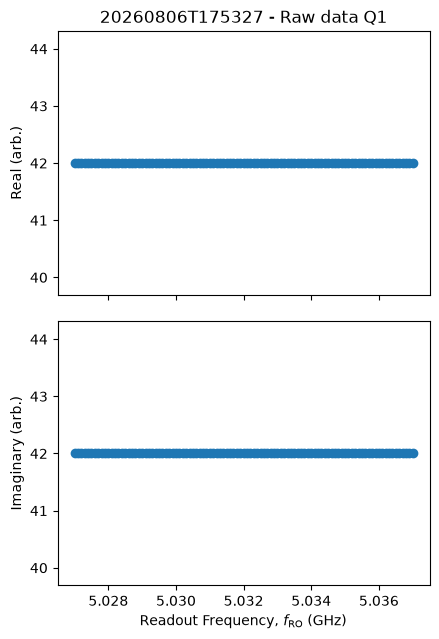

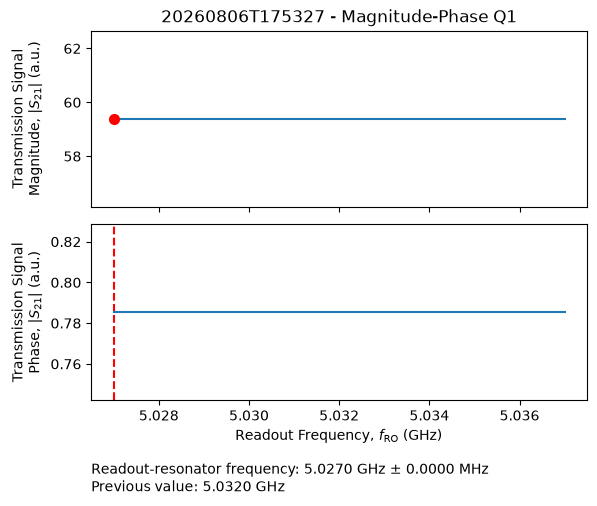

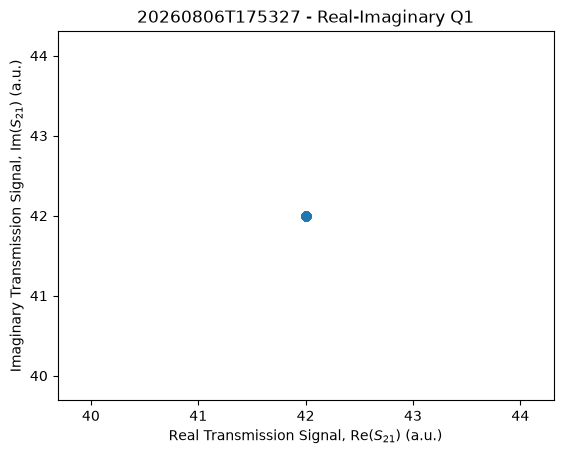

In [14]:
options = resonator_spectroscopy.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False)

qubit_to_measure = qubits[0]

frequencies = qubits[0].parameters.readout_resonator_frequency + np.linspace(
    -freq_range / 2, freq_range / 2, n_points
)

exp_workflow = resonator_spectroscopy.experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    frequencies=frequencies,
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [15]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result= workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
resonator_spectroscopy.update_qpu(qpu, qubit_parameters["new_parameter_values"])
print("\nReadout resonator frequency: ", qubit_to_measure.parameters.readout_resonator_frequency * 1e-9, ' GHz')

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'readout_resonator_frequency': 5027000000.0+/-0}},
 'old_parameter_values': {'Q1': {'readout_resonator_frequency': 5032000000.0}}}

Readout resonator frequency:  5.027  GHz


In [16]:
qubits[0]

TunableTransmonQubit(
│   uid='Q1',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=0,
│   │   ge_T2=0,
│   │   ge_T2_star=0,
│   │   ef_T1=0,
│   │   ef_T2=0,
│   │   ef_T2_star=0,
│   │   drive_lo_frequency=3600000000.0,
│   │   readout_lo_frequency=5000000000.0,
│   │   resonance_frequency_ge=3748000000.0,
│   │   resonance_frequency_ef=3508000000.0,
│   │   readout_resonator_frequency=5027000000.0,
│   │   ge_drive_amplitude_pi=0.2,
│   │   ge_drive_amplitude_pi2=0.1,
│   │   ge_drive_length=5e-08,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0,
│   │   │   'sigma': 0.25
│   │   },
│   │   ef_drive_amplitude_pi=0.2,
│   │   ef_drive_amplitude_pi2=0.1,
│   │   ef_drive_length=5e-08,
│   │   ef_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0,
│   │   │  

## Qubit Spectroscopy

#### Experiment Parameters

In [17]:
update_global_parameters = True

spectroscopy_length = 2e-6
spectroscopy_amplitude = 1
readout_amplitude = 0.1
drive_range = -30
n_avg_exponent = 13

freq_range = 100e6
n_points = 251

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.spectroscopy_length = spectroscopy_length
temp_pars.spectroscopy_amplitude = spectroscopy_amplitude
temp_pars.readout_amplitude = readout_amplitude
temp_pars.drive_range = drive_range
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.06 17:53:29.556] INFO    Starting LabOne Q Compiler run...
[2026.08.06 17:53:29.557] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.08.06 17:53:29.558] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.08.06 17:53:29.558] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.08.06 17:53:29.559] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.08.06 17:53:29.561] INFO    Schedule completed. [0.002 s]
[2026.08.06 17:53:29.566] INFO    Code generation completed for all AWGs. [0.005 s]
[2026.08.06 17:53:29.567] INFO    Completed compilation step 1 of 1. [0.008 s]
[2026.08.06 17:53:29.569] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.08.06 17:53:29.569] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.08.06 17:53:29.570] INFO     ───────────────────

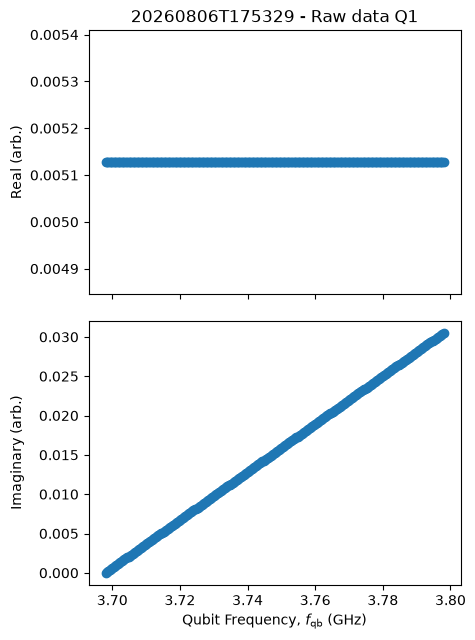

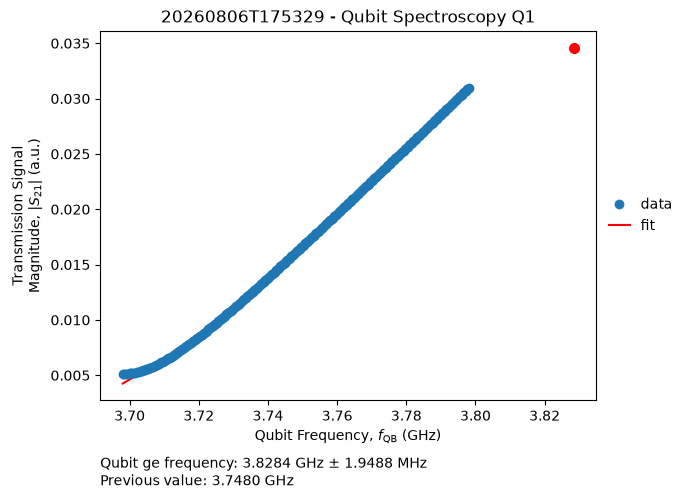

In [18]:
options = qubit_spectroscopy.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.update(False) 
options.close_figures(False)

qubits_to_measure = [qubits[0]]

frequencies = [
    temporary_parameters[q.uid].resonance_frequency_ge + np.linspace(- freq_range / 2, freq_range / 2, n_points)
    for q in qubits_to_measure
]
exp_workflow = qubit_spectroscopy.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    frequencies=frequencies,
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [19]:
manual_center_frequency = 3.75e9
temporary_parameters[qubit_to_measure.uid].resonance_frequency_ge = manual_center_frequency

In [20]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result= workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
qubit_spectroscopy.update_qpu(qpu, qubit_parameters["new_parameter_values"])
print("Readout resonance frequency ge: ", qubit_to_measure.parameters.resonance_frequency_ge)

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'resonance_frequency_ge': 3828385073.3752136+/-1948751.8628151563}},
 'old_parameter_values': {'Q1': {'resonance_frequency_ge': 3748000000.0}}}
Readout resonance frequency ge:  3828385073.3752136


# Control Pulses

## Amplitude Rabi

#### Experiment Parameters

In [21]:
update_global_parameters = True

transition = set_transition('ge')

drive_range = -5
drive_length = 50e-9
readout_amplitude = 0.5
n_avg_exponent = 13

amp_min = 0
amp_max = 1
n_amp = 21

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.drive_range = drive_range
temp_pars.readout_amplitude = readout_amplitude
if transition == 'ge':
    temp_pars.ge_drive_length = drive_length
elif transition == 'ef':
    temp_pars.ef_drive_length = drive_length
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.06 17:53:31.437] INFO    Starting LabOne Q Compiler run...
[2026.08.06 17:53:31.438] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.08.06 17:53:31.438] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.08.06 17:53:31.439] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.08.06 17:53:31.439] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.08.06 17:53:31.440] INFO    Schedule completed. [0.000 s]
[2026.08.06 17:53:31.442] INFO    Code generation completed for all AWGs. [0.002 s]
[2026.08.06 17:53:31.442] INFO    Completed compilation step 1 of 1. [0.003 s]
[2026.08.06 17:53:31.444] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.08.06 17:53:31.444] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.08.06 17:53:31.444] INFO     ───────────────────

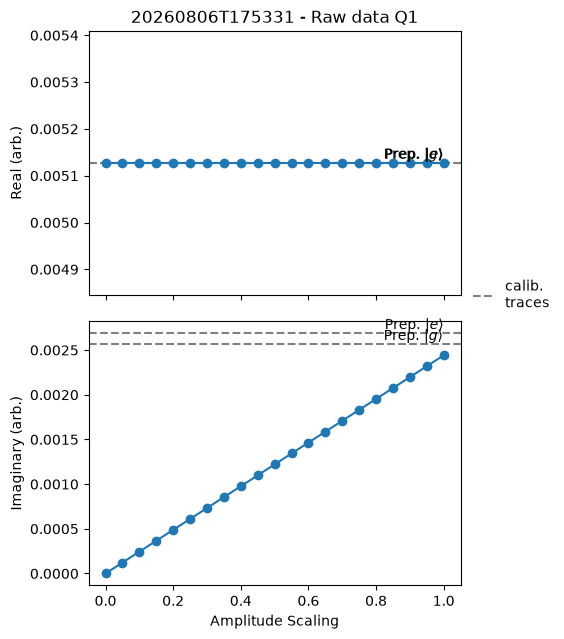

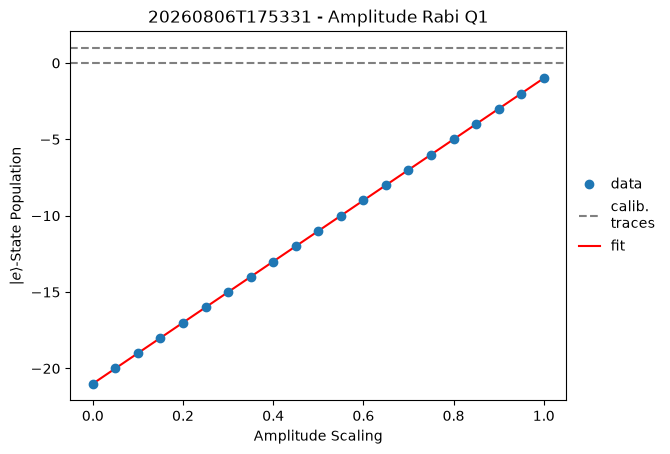

In [22]:
options = amplitude_rabi.experiment_workflow.options()

options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = amplitude_rabi.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [26]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
amplitude_rabi.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("Drive amplitude pi ge: ", qubit_to_measure.parameters.ge_drive_amplitude_pi)
    print("Drive amplitude pi2 ge: ", qubit_to_measure.parameters.ge_drive_amplitude_pi2)
elif transition == 'ef':
    print("Drive amplitude pi ef: ", qubit_to_measure.parameters.ef_drive_amplitude_pi)
    print("Drive amplitude pi2 ef: ", qubit_to_measure.parameters.ef_drive_amplitude_pi2)

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'ge_T2_star': 0.10212395641342753+/-8437.16395674593,
                                 'resonance_frequency_ge': 3828208904.7837887+/-256775.9170186083}},
 'old_parameter_values': {'Q1': {'ge_T2_star': 0,
                                 'resonance_frequency_ge': 3828385073.3752136}}}
Drive amplitude pi ge:  0.2
Drive amplitude pi2 ge:  0.1


## Ramsey

#### Experiment Parameters

In [27]:
update_global_parameters = True

detuning = 0.5e6
transition = set_transition('ge')

n_avg_exponent = 13

delay_min = 0
delay_max = 25e-6
n_delay = 201

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.06 17:53:43.680] INFO    Starting LabOne Q Compiler run...
[2026.08.06 17:53:43.681] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.08.06 17:53:43.682] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.08.06 17:53:43.682] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.08.06 17:53:43.682] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.08.06 17:53:43.685] INFO    Schedule completed. [0.002 s]
[2026.08.06 17:53:43.690] INFO    Code generation completed for all AWGs. [0.005 s]
[2026.08.06 17:53:43.691] INFO    Completed compilation step 1 of 1. [0.008 s]
[2026.08.06 17:53:43.692] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.08.06 17:53:43.693] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.08.06 17:53:43.693] INFO     ───────────────────

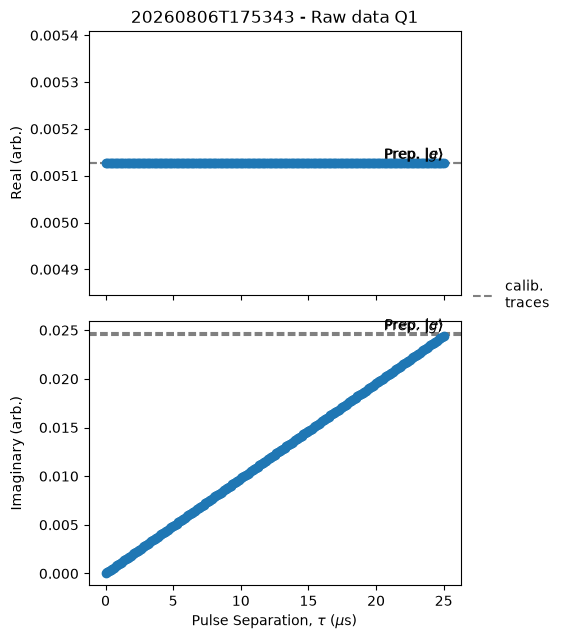

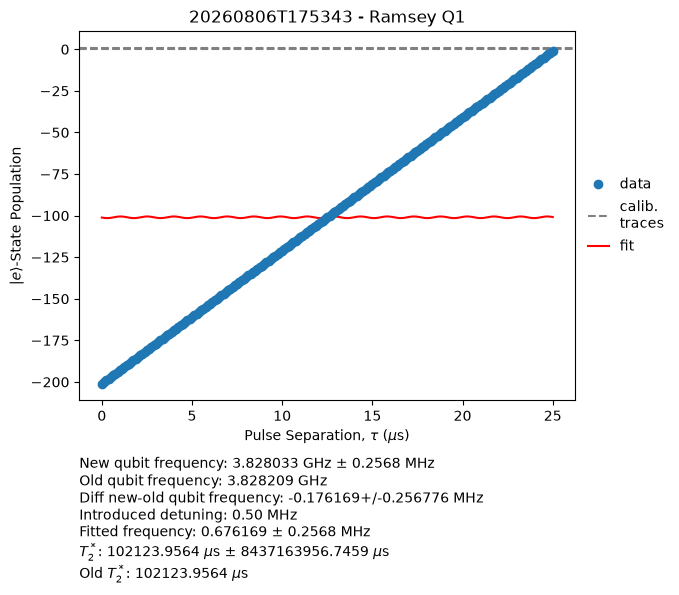

In [28]:
options = ramsey.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

# Note: if neighbouring qubits are physically coupled by a resonator,
# you usually don't want to run Ramsey in parallel on them because
# your result will be skewed by strong residual-ZZ coupling.
# Next-nearest neighbours is typically okay.
# qubits_to_measure = [qubits[0], qubits[2]]
qubits_to_measure = [qubits[0]]

delays = [
    np.linspace(delay_min, delay_max, n_delay)
]
detunings = [
    detuning
]

exp_workflow = ramsey.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    detunings=detunings,
    options=options,
    temporary_parameters=temporary_parameters
)

workflow_result = exp_workflow.run()

#### Update Parameters

In [29]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
ramsey.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("ge_T2_star: ", qubit_to_measure.parameters.ge_T2_star)
    print("resonance_frequency_ge: ", qubit_to_measure.parameters.resonance_frequency_ge)
elif transition == 'ef':
    print("ef_T2_star: ", qubit_to_measure.parameters.ef_T2_star)
    print("resonance_frequency_ef: ", qubit_to_measure.parameters.resonance_frequency_ef)

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'ge_T2_star': 0.10212395641342753+/-8437.16395674593,
                                 'resonance_frequency_ge': 3828032736.1923637+/-256775.9170186083}},
 'old_parameter_values': {'Q1': {'ge_T2_star': 0.10212395641342753,
                                 'resonance_frequency_ge': 3828208904.7837887}}}
ge_T2_star:  0.10212395641342753
resonance_frequency_ge:  3828032736.1923637


## T1 Lifetime

#### Experiment Parameters

In [30]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

delay_min = 0
delay_max = 100e-6
n_delay = 51
log_spacing = True

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.06 17:53:44.786] INFO    Starting LabOne Q Compiler run...
[2026.08.06 17:53:44.787] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.08.06 17:53:44.787] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.08.06 17:53:44.788] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.08.06 17:53:44.788] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.08.06 17:53:44.789] INFO    Schedule completed. [0.000 s]
[2026.08.06 17:53:44.792] INFO    Code generation completed for all AWGs. [0.003 s]
[2026.08.06 17:53:44.793] INFO    Completed compilation step 1 of 1. [0.004 s]
[2026.08.06 17:53:44.794] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.08.06 17:53:44.795] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.08.06 17:53:44.795] INFO     ───────────────────

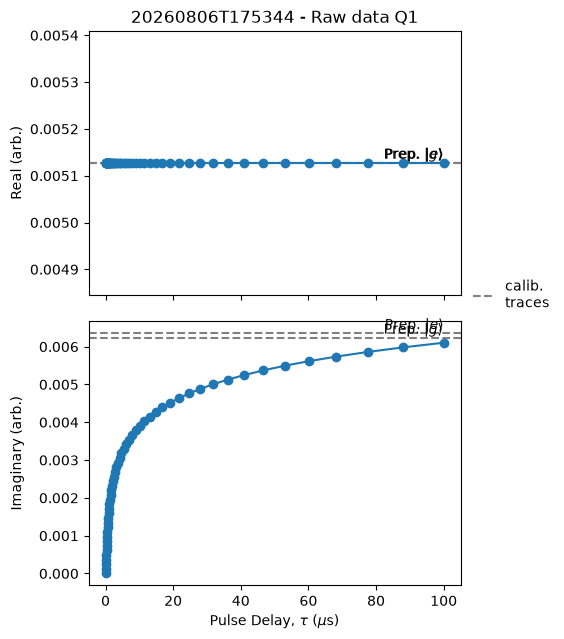

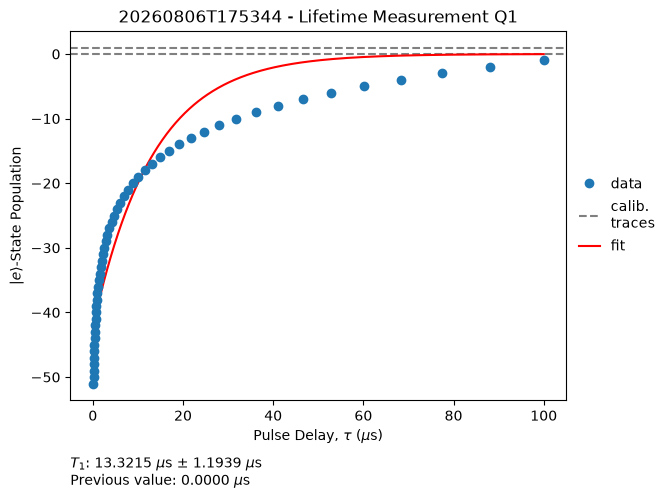

In [31]:
options = lifetime_measurement.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures


qubits_to_measure = [qubits[0]]

if log_spacing:
    delays = [log_sweep_help(delay_min, delay_max, n_delay)]
else:
    delays = [np.linspace(delay_min, delay_max, n_delay)]

exp_workflow = lifetime_measurement.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    options=options,
    temporary_parameters=temporary_parameters 
)

workflow_result = exp_workflow.run()

#### Update Parameters

In [32]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
ramsey.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("ge_T1: ", qubit_to_measure.parameters.ge_T1)
elif transition == 'ef':
    print("ef_T1: ", qubit_to_measure.parameters.ef_T1)

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'ge_T1': 1.3321531837298236e-05+/-1.1938771948035232e-06}},
 'old_parameter_values': {'Q1': {'ge_T1': 0}}}
ge_T1:  1.3321531837298236e-05


## DRAG Calibration

#### Experiment Parameters

In [33]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

q_min = -0.05
q_max = 0.05
n_q = 31

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.06 17:53:46.467] INFO    Starting LabOne Q Compiler run...
[2026.08.06 17:53:46.468] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.08.06 17:53:46.468] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.08.06 17:53:46.469] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.08.06 17:53:46.469] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.08.06 17:53:46.470] INFO    Schedule completed. [0.001 s]
[2026.08.06 17:53:46.480] INFO    Code generation completed for all AWGs. [0.010 s]
[2026.08.06 17:53:46.481] INFO    Completed compilation step 1 of 1. [0.012 s]
[2026.08.06 17:53:46.483] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.08.06 17:53:46.483] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.08.06 17:53:46.483] INFO     ───────────────────

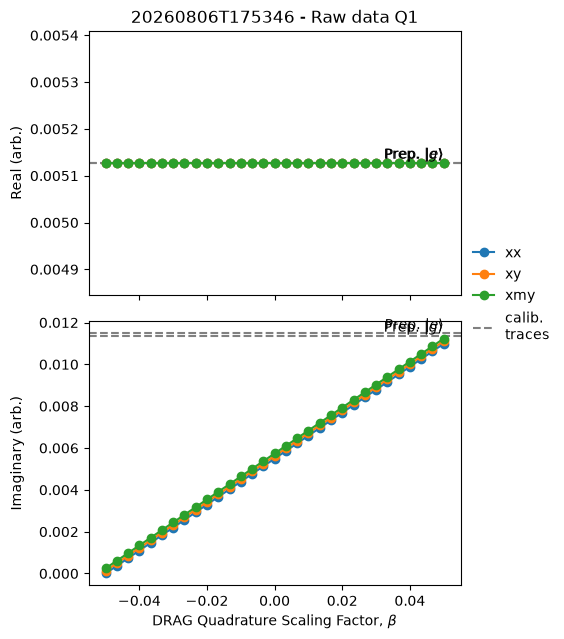

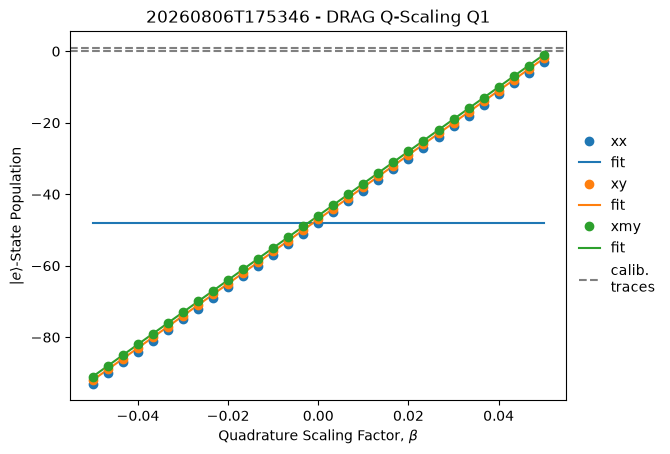

In [34]:
options = drag_q_scaling.experiment_workflow.options()
# options.update(True)  # updates the qubit parameter 'ge_drive_pulse["beta"]'
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = drag_q_scaling.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    q_scalings=[np.linspace(q_min, q_max, n_q) for _ in qubits_to_measure],
    options=options,
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [35]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    print('Updated global experiment parameters!\n')

analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
ramsey.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("ge_drive_pulse[beta]: ", qubit_to_measure.parameters.ge_drive_pulse["beta"])
elif transition == 'ef':
    print("ef_drive_pulse[beta]: ", qubit_to_measure.parameters.ef_drive_pulse["beta"])

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {}},
 'old_parameter_values': {'Q1': {'ge_drive_pulse.beta': 0}}}


RuntimeError: Workflow log messages are currently not supported outside of tasks.

## Hahn-Echo

#### Experiment Parameters

In [36]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

delay_min = 0
delay_max = 100e-6
n_delay = 51
log_spacing = True

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.06 17:53:49.346] INFO    Starting LabOne Q Compiler run...
[2026.08.06 17:53:49.347] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.08.06 17:53:49.347] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.08.06 17:53:49.347] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.08.06 17:53:49.348] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.08.06 17:53:49.349] INFO    Schedule completed. [0.001 s]
[2026.08.06 17:53:49.352] INFO    Code generation completed for all AWGs. [0.003 s]
[2026.08.06 17:53:49.352] INFO    Completed compilation step 1 of 1. [0.004 s]
[2026.08.06 17:53:49.354] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.08.06 17:53:49.354] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.08.06 17:53:49.354] INFO     ───────────────────

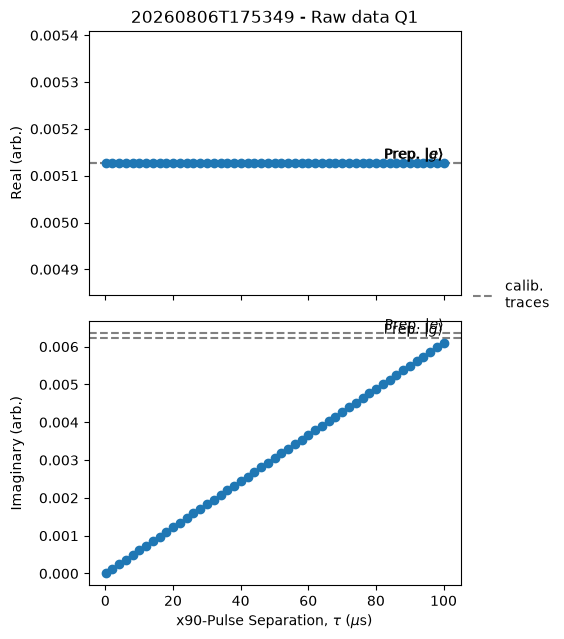

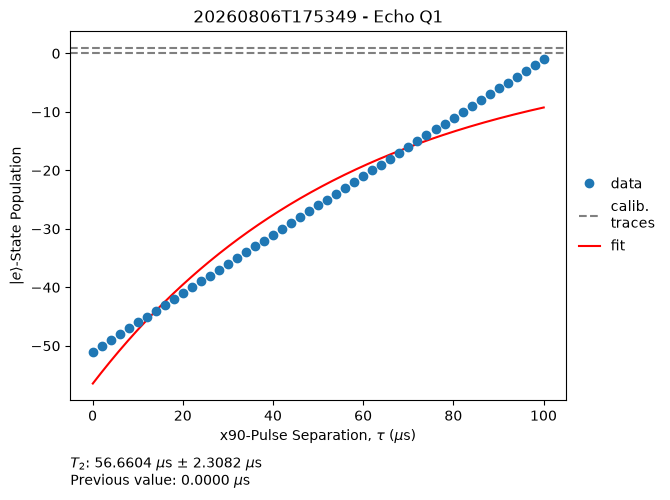

In [37]:
options = echo.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False)

options.transition(transition)
options.cal_states(transition)

# Note: if neighbouring qubits are physically coupled by a resonator,
# you usually don't want to run Echo in parallel on them because
# your result will be skewed by strong residual-ZZ coupling.
# Next-nearest neighbours is typically okay.
qubits_to_measure = [qubits[0]]

delays = [
    np.linspace(delay_min, delay_max, n_delay)
]

exp_workflow = echo.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    options=options,
    temporary_parameters=temporary_parameters
)

workflow_result = exp_workflow.run()

#### Update Parameters

In [38]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)
ramsey.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("ge_T2: ", qubit_to_measure.parameters.ge_T2)
elif transition == 'ef':
    print("ef_T2: ", qubit_to_measure.parameters.ef_T2)

Updated global experiment parameters!

{'new_parameter_values': {'Q1': {'ge_T2': 5.666042542233106e-05+/-2.3081934191142103e-06}},
 'old_parameter_values': {'Q1': {'ge_T2': 0}}}
ge_T2:  5.666042542233106e-05


# Readout Optimization

Optimization of the readout pulse amplitude and of the readout (resonator)
frequency.

1. **Readout Amplitude Optimization** — sweep the readout amplitude and run an
   amplitude-Rabi experiment at each amplitude. The readout amplitude with the
   smallest relative Rabi-fit errors gives the best signal-to-noise ratio.
2. **Dispersive Shift** — resonator spectroscopy with the qubit prepared in
   g, e (and f). The optimal readout frequency is the frequency of the largest
   distance between the transmission signals of the different states.
3. **Readout Settings Summary** — write the optimized readout parameters into
   the QPU and save them.

In [41]:
qpu.quantum_elements

[TunableTransmonQubit(
│   uid='Q1',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=1.3321531837298236e-05,
│   │   ge_T2=5.666042542233106e-05,
│   │   ge_T2_star=0.10212395641342753,
│   │   ef_T1=0,
│   │   ef_T2=0,
│   │   ef_T2_star=0,
│   │   drive_lo_frequency=3600000000.0,
│   │   readout_lo_frequency=5000000000.0,
│   │   resonance_frequency_ge=3828032736.1923637,
│   │   resonance_frequency_ef=3508000000.0,
│   │   readout_resonator_frequency=5027000000.0,
│   │   ge_drive_amplitude_pi=0.2,
│   │   ge_drive_amplitude_pi2=0.1,
│   │   ge_drive_length=5e-08,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0,
│   │   │   'sigma': 0.25
│   │   },
│   │   ef_drive_amplitude_pi=0.2,
│   │   ef_drive_amplitude_pi2=0.1,
│   │   ef_drive_length=5e-08,
│   │   ef_drive_pulse={


## Readout Amplitude Optimization

#### Experiment Parameters

In [47]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 12

# readout setting used during the sweep
readout_range_out = -20
readout_range_in = -45
readout_length = 2e-6
readout_integration_length = 2e-6
readout_integration_delay = 80e-9
reset_delay_length = 150e-6

# length and amplitude are taken from readout_length / readout_amplitude
readout_pulse = {
    'function': 'gaussian_square',
    'width': readout_length * 0.95,
}

# readout amplitude sweep
ro_amp_min = 0.0
ro_amp_max = 1.0
n_ro_amp = 11
ro_amp_arr = np.linspace(ro_amp_min, ro_amp_max, n_ro_amp)

# rabi sweep used to benchmark each readout amplitude
drive_range = -5
amp_min = 0
amp_max = 1
n_amp = 21
drive_amplitudes = np.linspace(amp_min, amp_max, n_amp)

qubit_to_measure = qubits[0]

#### Run Workflow

In [48]:
options = amplitude_rabi.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.update(False) # never update the qubit parameters during the sweep
options.close_figures(True) # one Rabi figure per readout amplitude

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubit_to_measure]

rabi_ro_sweep_results = []
fit_values_ro_sweep = []
fit_errors_ro_sweep = []
# same order as the old popt/pcov of fit_Rabi
fit_parameter_names = ['frequency', 'phase', 'amplitude', 'offset']

for ro_amp in ro_amp_arr:
    print('Measure at readout amplitude:', round(ro_amp, 5))

    temporary_parameters = {}
    temp_pars = deepcopy(qubits[0].parameters)
    temp_pars.readout_amplitude = round(ro_amp, 5)
    temp_pars.readout_length = readout_length
    temp_pars.readout_pulse = readout_pulse
    temp_pars.readout_integration_length = readout_integration_length
    temp_pars.readout_integration_delay = readout_integration_delay
    temp_pars.readout_range_out = readout_range_out
    temp_pars.readout_range_in = readout_range_in
    temp_pars.reset_delay_length = reset_delay_length
    temp_pars.drive_range = drive_range
    temporary_parameters[qubit_to_measure.uid] = temp_pars

    exp_workflow = amplitude_rabi.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[q.uid for q in qubits_to_measure],
        amplitudes=[drive_amplitudes for q in qubits_to_measure],
        options=options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result = exp_workflow.run()
    rabi_ro_sweep_results.append(workflow_result)

    # rotates/projects the raw data and fits a cosine model to the population
    fit_results = get_analysis_task_output(workflow_result, 'fit_data')
    fit_res = fit_results.get(qubit_to_measure.uid)
    if fit_res is None:
        print(f'  Rabi fit failed at readout amplitude {round(ro_amp, 5)}.')
        fit_values_ro_sweep.append([np.nan] * len(fit_parameter_names))
        fit_errors_ro_sweep.append([np.nan] * len(fit_parameter_names))
        continue

    fit_values_ro_sweep.append([fit_res.params[p].value for p in fit_parameter_names])
    fit_errors_ro_sweep.append([fit_res.params[p].stderr for p in fit_parameter_names])

popt_rabi_arr = np.array(fit_values_ro_sweep, dtype=float)
err_arr = np.array(fit_errors_ro_sweep, dtype=float)

Measure at readout amplitude: 0.0
[2026.08.06 18:04:19.722] INFO    Starting LabOne Q Compiler run...
[2026.08.06 18:04:19.724] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.08.06 18:04:19.724] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.08.06 18:04:19.724] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.08.06 18:04:19.725] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.08.06 18:04:19.725] INFO    Schedule completed. [0.000 s]
[2026.08.06 18:04:19.728] INFO    Code generation completed for all AWGs. [0.002 s]
[2026.08.06 18:04:19.728] INFO    Completed compilation step 1 of 1. [0.003 s]
[2026.08.06 18:04:19.730] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.08.06 18:04:19.730] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.08.06 18:04:19

#### Update Parameters

/var/folders/_0/lzygm67s7vd51wm7d39fyhg00000gn/T/ipykernel_97483/3691080377.py:24: RuntimeWarning: Mean of empty slice
  mean_rel_err = np.nanmean(rel_err_arr, axis=1)


ValueError: All-NaN slice encountered

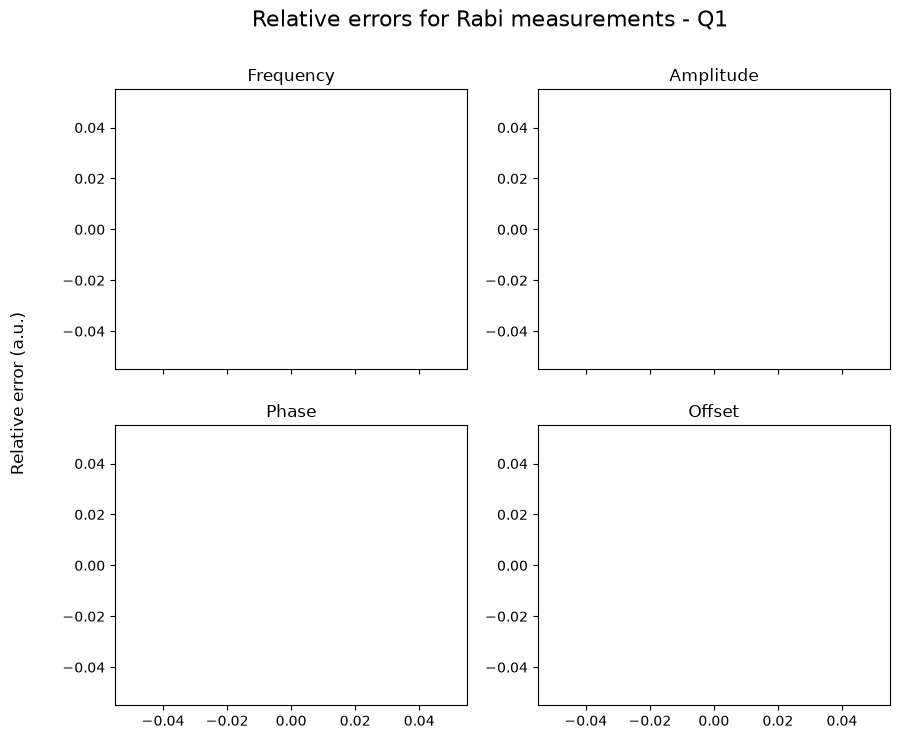

In [51]:
ll = 1 # skip readout amplitude 0 (no signal)
ul = None
sweep_slice = slice(ll, ul)

# lmfit reports stderr = 0 when the covariance matrix could not be estimated;
# treat those points as invalid instead of "perfect".
err_arr[err_arr == 0] = np.nan
rel_err_arr = np.abs(err_arr / popt_rabi_arr)
fig, ax = plt.subplots(2, 2, sharex=True, figsize=(10, 8))
fig.suptitle(f'Relative errors for Rabi measurements - {qubit_to_measure.uid}', fontsize=16)
fig.supylabel('Relative error (a.u.)')

ax[0, 0].plot(ro_amp_arr[sweep_slice], rel_err_arr[sweep_slice, 0], '.k', label='freq')
ax[1, 0].plot(ro_amp_arr[sweep_slice], rel_err_arr[sweep_slice, 1], '.k', label='phase')
ax[0, 1].plot(ro_amp_arr[sweep_slice], rel_err_arr[sweep_slice, 2], '.k', label='amp')
ax[1, 1].plot(ro_amp_arr[sweep_slice], rel_err_arr[sweep_slice, 3], '.k', label='off')

ax[0, 0].set_title('Frequency')
ax[1, 0].set_title('Phase')
ax[0, 1].set_title('Amplitude')
ax[1, 1].set_title('Offset')

# Optimal readout amplitude: smallest mean relative fit error.
mean_rel_err = np.nanmean(rel_err_arr, axis=1)
masked_rel_err = np.full(mean_rel_err.shape, np.nan)
masked_rel_err[sweep_slice] = mean_rel_err[sweep_slice]
optimal_index = int(np.nanargmin(masked_rel_err))
readout_amplitude_opt = float(ro_amp_arr[optimal_index])

for axis in ax.flatten():
    axis.axvline(x=readout_amplitude_opt, ls='-.', color='r', label='optimal')
    axis.legend()

print('Optimal readout amplitude:', round(readout_amplitude_opt, 5))

figname = f'Rabi_optimiz_{readout_range_out}dBm_'
file_path = get_path_to_file(figname, '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [52]:
# Set to a value != None to override the value extracted above.
manual_readout_amplitude = None
if manual_readout_amplitude is not None:
    readout_amplitude_opt = float(manual_readout_amplitude)

if update_global_parameters:
    temporary_parameters[qubit_to_measure.uid].readout_amplitude = readout_amplitude_opt
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

print('Readout amplitude: ', qubit_to_measure.parameters.readout_amplitude)
print('Readout length: ', qubit_to_measure.parameters.readout_length)
print('Readout pulse: ', qubit_to_measure.parameters.readout_pulse)
print('Readout integration length: ', qubit_to_measure.parameters.readout_integration_length)
print('Readout integration delay: ', qubit_to_measure.parameters.readout_integration_delay)
print('Readout range out / in: ', qubit_to_measure.parameters.readout_range_out,
      '/', qubit_to_measure.parameters.readout_range_in)

NameError: name 'readout_amplitude_opt' is not defined

## Dispersive Shift

Resonator spectroscopy with the qubit prepared in different states
(old: *Spectroscopy of resonator in different states*, `create_res_spec_gef`
with `level = 0, 1, 2`). Use `states = 'ge'` if the e-f transition is not
calibrated yet.

#### Experiment Parameters

In [53]:
update_global_parameters = True

states = 'gef'

n_avg_exponent = 12 

freq_range = 2e6
n_points = 101

readout_amplitude = 0.2
readout_range_out = -25
readout_range_in = -45
reset_delay_length = 120e-6

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.readout_amplitude = readout_amplitude
temp_pars.readout_range_out = readout_range_out
temp_pars.readout_range_in = readout_range_in
temp_pars.reset_delay_length = reset_delay_length
temporary_parameters[qubits[0].uid] = temp_pars

#### Run Workflow

[2026.08.06 18:25:35.306] INFO    Starting LabOne Q Compiler run...
[2026.08.06 18:25:35.308] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.08.06 18:25:35.309] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.08.06 18:25:35.315] INFO    Schedule completed. [0.003 s]
[2026.08.06 18:25:35.322] INFO    Code generation completed for all AWGs. [0.007 s]
[2026.08.06 18:25:35.323] INFO    Completed compilation step 1 of 1. [0.011 s]
[2026.08.06 18:25:35.325] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.08.06 18:25:35.325] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.08.06 18:25:35.325] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.08.06 18:25:35.325] INFO      SHFQC_DEV12192        0         33            0           1      8000  
[2026.08.06 18:25:35.326] INFO      SHFQC_DEV12192_sg   

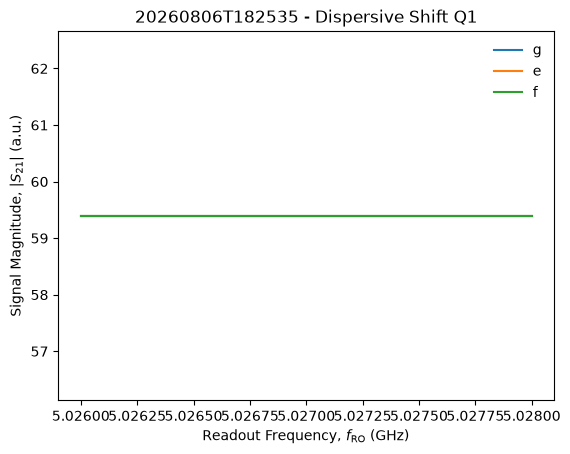

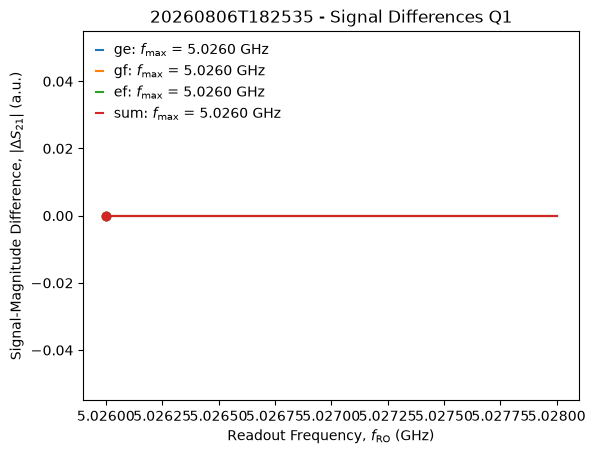

In [56]:
options = dispersive_shift.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.update(False)  # updated explicitly below
options.close_figures(False)

qubit_to_measure = qubits[0]

frequencies = temporary_parameters[
    qubit_to_measure.uid
].readout_resonator_frequency + np.linspace(-freq_range / 2, freq_range / 2, n_points)

exp_workflow = dispersive_shift.experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    frequencies=frequencies,
    states=states,
    options=options,
    temporary_parameters=temporary_parameters,
)
workflow_result = exp_workflow.run()

#### Analysis Plots

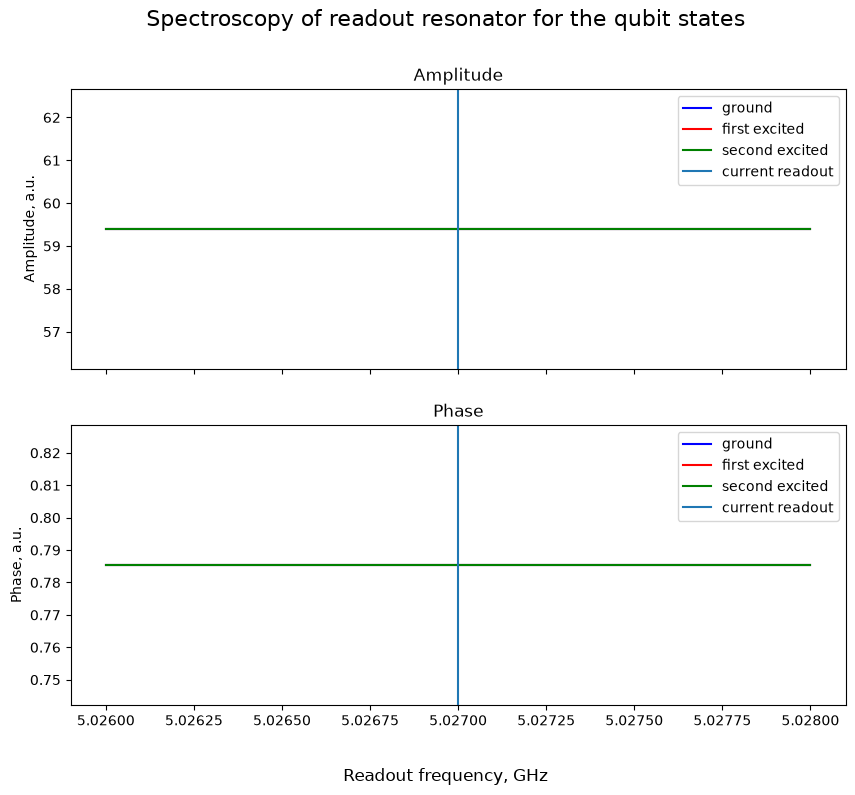

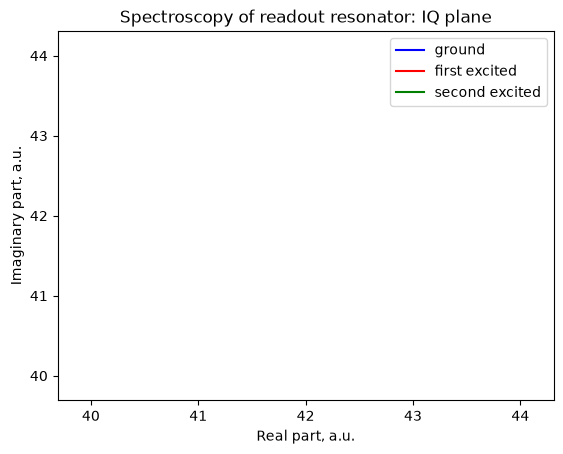

In [57]:
result = workflow_result.output
res_data = {
    state: result[dsl.handles.result_handle(qubit_to_measure.uid, suffix=state)].data
    for state in states
}
res_freq = frequencies

state_labels = {'g': 'ground', 'e': 'first excited', 'f': 'second excited'}
state_colors = {'g': 'b', 'e': 'r', 'f': 'g'}

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
fig.suptitle('Spectroscopy of readout resonator for the qubit states', fontsize=16)
fig.supxlabel('Readout frequency, GHz')

ax[0].set_title('Amplitude')
ax[1].set_title('Phase')

for state, data in res_data.items():
    ax[0].plot(res_freq * 1e-9, np.abs(data), state_colors[state], label=state_labels[state])
    ax[1].plot(res_freq * 1e-9, np.unwrap(np.angle(data)), state_colors[state],
               label=state_labels[state])

for axis, ylabel in zip(ax, ['Amplitude, a.u.', 'Phase, a.u.']):
    axis.axvline(x=qubit_to_measure.parameters.readout_resonator_frequency * 1e-9,
                 label='current readout')
    axis.set_ylabel(ylabel)
    axis.legend()

file_path = get_path_to_file('Readout_spec_for_g_e', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

fig_iq, ax_iq = plt.subplots()
ax_iq.set_title('Spectroscopy of readout resonator: IQ plane')
for state, data in res_data.items():
    ax_iq.plot(data.real, data.imag, state_colors[state], label=state_labels[state])
ax_iq.set_xlabel('Real part, a.u.')
ax_iq.set_ylabel('Imaginary part, a.u.')
ax_iq.legend()

file_path = get_path_to_file('Readout_spec_for_g_e_IQ', '.png')
fig_iq.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

ge: max distance 0 at 5.026000 GHz
gf: max distance 0 at 5.026000 GHz
ef: max distance 0 at 5.026000 GHz
sum: max distance 0 at 5.026000 GHz


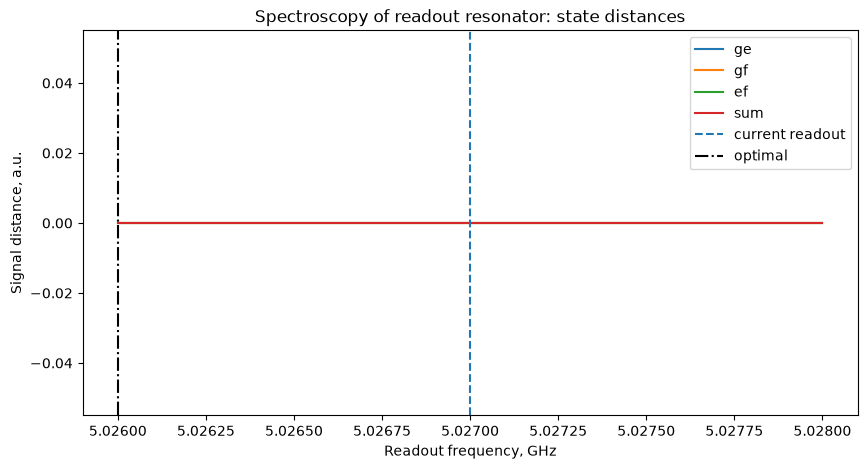

In [58]:
processed_data_dict = get_analysis_task_output(workflow_result, 'calculate_signal_differences')

fig_dist, ax_dist = plt.subplots(figsize=(10, 5))
ax_dist.set_title('Spectroscopy of readout resonator: state distances')
for state_pair, (distance, max_distance, freq_at_max) in processed_data_dict.items():
    ax_dist.plot(res_freq * 1e-9, distance, label=state_pair)
    print(f'{state_pair}: max distance {max_distance:.4g} at '
          f'{freq_at_max * 1e-9:.6f} GHz')

ax_dist.axvline(x=qubit_to_measure.parameters.readout_resonator_frequency * 1e-9,
                ls='--', label='current readout')
ax_dist.axvline(x=processed_data_dict['sum' if 'sum' in processed_data_dict else
                                      next(iter(processed_data_dict))][2] * 1e-9,
                ls='-.', color='k', label='optimal')
ax_dist.set_xlabel('Readout frequency, GHz')
ax_dist.set_ylabel('Signal distance, a.u.')
ax_dist.legend()

file_path = get_path_to_file('Readout_spec_for_g_e_distance', '.png')
fig_dist.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [59]:
analysis_workflow_result = workflow_result.tasks['analysis_workflow']
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

readout_resonator_frequency_opt = float(
    qubit_parameters['new_parameter_values'][qubit_to_measure.uid][
        'readout_resonator_frequency'
    ]
)

manual_readout_resonator_frequency = None
if manual_readout_resonator_frequency is not None:
    readout_resonator_frequency_opt = float(manual_readout_resonator_frequency)
    qubit_parameters['new_parameter_values'][qubit_to_measure.uid][
        'readout_resonator_frequency'
    ] = readout_resonator_frequency_opt

print(f'ro freq opt: {readout_resonator_frequency_opt * 1e-9:.6f} GHz')

if update_global_parameters:
    temporary_parameters[qubit_to_measure.uid].readout_resonator_frequency = (
        readout_resonator_frequency_opt
    )
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    dispersive_shift.update_qpu(qpu, qubit_parameters['new_parameter_values'])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

print('Readout resonator frequency: ',
      qubit_to_measure.parameters.readout_resonator_frequency * 1e-9, ' GHz')

{'new_parameter_values': {'Q1': {'readout_resonator_frequency': np.float64(5026000000.0)}},
 'old_parameter_values': {'Q1': {'readout_resonator_frequency': 5027000000.0}}}
ro freq opt: 5.026000 GHz
Updated global experiment parameters!

Readout resonator frequency:  5.026000000000001  GHz


In [60]:
data_gef_spec = {'freq': res_freq}
for state, data in res_data.items():
    data_gef_spec[f'{state}_res'] = data
    data_gef_spec[f'{state}_freq'] = res_freq
data_gef_spec.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_gef_spec['sample_name'] = sample_name
data_gef_spec['qubit_name'] = qubit_name
data_gef_spec['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('ge_spec_readout_', '.mat')
savemat(file_path, data_gef_spec)
print(f'Saved gef readout spectroscopy to: {file_path}')

Saved gef readout spectroscopy to: N:\/xld/qubit_thermometry_v2/ES-008-BC_2-1_8853_CD2/COOLDOWN_2026-08-04/Q1/20260806_182541_ge_spec_readout_.mat


In [61]:
readout_opt = {
    'readout_amplitude': qubit_to_measure.parameters.readout_amplitude,
    'readout_length': qubit_to_measure.parameters.readout_length,
    'readout_pulse': qubit_to_measure.parameters.readout_pulse,
    'readout_integration_length': qubit_to_measure.parameters.readout_integration_length,
    'readout_integration_delay': qubit_to_measure.parameters.readout_integration_delay,
    'readout_integration_kernels_type':
        qubit_to_measure.parameters.readout_integration_kernels_type,
    'readout_resonator_frequency': qubit_to_measure.parameters.readout_resonator_frequency,
    'readout_lo_frequency': qubit_to_measure.parameters.readout_lo_frequency,
    'readout_range_out': qubit_to_measure.parameters.readout_range_out,
    'readout_range_in': qubit_to_measure.parameters.readout_range_in,
    'reset_delay_length': qubit_to_measure.parameters.reset_delay_length,
}
pprint(readout_opt)

{'readout_amplitude': 0.2,
 'readout_integration_delay': 8e-08,
 'readout_integration_kernels_type': 'default',
 'readout_integration_length': 2e-06,
 'readout_length': 2e-06,
 'readout_lo_frequency': 5000000000.0,
 'readout_pulse': {'function': 'const'},
 'readout_range_in': -45,
 'readout_range_out': -25,
 'readout_resonator_frequency': np.float64(5026000000.0),
 'reset_delay_length': 0.00012}


In [62]:
qubits[0]

TunableTransmonQubit(
│   uid='Q1',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=1.3321531837298236e-05,
│   │   ge_T2=5.666042542233106e-05,
│   │   ge_T2_star=0.10212395641342753,
│   │   ef_T1=0,
│   │   ef_T2=0,
│   │   ef_T2_star=0,
│   │   drive_lo_frequency=3600000000.0,
│   │   readout_lo_frequency=5000000000.0,
│   │   resonance_frequency_ge=3828032736.1923637,
│   │   resonance_frequency_ef=3508000000.0,
│   │   readout_resonator_frequency=np.float64(5026000000.0),
│   │   ge_drive_amplitude_pi=0.2,
│   │   ge_drive_amplitude_pi2=0.1,
│   │   ge_drive_length=5e-08,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0,
│   │   │   'sigma': 0.25
│   │   },
│   │   ef_drive_amplitude_pi=0.2,
│   │   ef_drive_amplitude_pi2=0.1,
│   │   ef_drive_length=5e-08,
│   │   ef_dri